# CO2 Emissions Prediction — Vehicle Engine Analysis

**Goal    :** Predict CO2 emissions (g/km) from engine specs.  
**Dataset :** Canada Vehicle Emissions — Government of Canada Open Data  
            - 7,000+ vehicles (2000–2022)  
            - Engine size, cylinders, fuel consumption → CO2  
**Models  :** Random Forest · SVR · Ridge  
**Why clean:** Features are physical measurements. Target is measured directly.  
              Zero risk of data leakage.  
**Author  :** Your Name

In [1]:
# libraries
!pip install shap -q

import warnings, os
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection  import train_test_split, cross_val_score, KFold
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import Ridge
from sklearn.svm              import SVR
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score

import shap
print("✅ Ready.")

✅ Ready.


In [7]:
# S1 — LOAD DATA
# Source: CO2 Emissions by Vehicles — Kaggle
# Official Canadian government vehicle emissions data

!pip install kagglehub -q
import kagglehub, os

path  = kagglehub.dataset_download("debajyotipodder/co2-emission-by-vehicles")
files = os.listdir(path)
print("Files available:", files)

csv   = [f for f in files if f.endswith('.csv')][0]
df    = pd.read_csv(os.path.join(path, csv))

print(f"\n✅ {df.shape[0]:,} vehicles · {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

# find the correct file
import os

print("All files in dataset:")
for f in os.listdir(path):
    print(f"  {f}")

# load all CSV files and show their shape + columns
for f in os.listdir(path):
    if f.endswith('.csv'):
        temp = pd.read_csv(os.path.join(path, f))
        print(f"\n--- {f} ---")
        print(f"  Shape: {temp.shape}")
        print(f"  Columns: {list(temp.columns[:5])}")

Using Colab cache for faster access to the 'co2-emission-by-vehicles' dataset.
Files available: ['CO2 Emissions_Canada.csv', 'Data Description.csv']

✅ 7,385 vehicles · 12 columns

Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']
All files in dataset:
  CO2 Emissions_Canada.csv
  Data Description.csv

--- CO2 Emissions_Canada.csv ---
  Shape: (7385, 12)
  Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders']

--- Data Description.csv ---
  Shape: (19, 2)
  Columns: ['Understanding the Data', 'Unnamed: 1']


In [8]:
# S2 — UNDERSTAND THE COLUMNS
# Physical features — every relationship makes real-world sense

print("""
Column Guide — CO2 Emissions Dataset
──────────────────────────────────────────────────────────
Make           → car brand (Toyota, BMW, Ford...)
Model          → car model name
Vehicle Class  → SUV, Sedan, Pickup, etc.
Engine Size    → engine displacement in liters (1.0 – 8.0)
               → BIGGER engine = more fuel = more CO2
Cylinders      → number of cylinders (3, 4, 6, 8, 10, 12)
               → MORE cylinders = more power = more CO2
Transmission   → A=Automatic, M=Manual, AV=CVT + gear count
Fuel Type      → X=Regular, Z=Premium, D=Diesel, E=Ethanol
Fuel Consumption City    → L/100km in city driving
Fuel Consumption Hwy     → L/100km on highway
Fuel Consumption Comb    → combined city+highway average
Fuel Consumption Comb(mpg) → same in miles per gallon
CO2 Emissions  → TARGET: grams of CO2 per kilometer
──────────────────────────────────────────────────────────
KEY PHYSICS:
  More fuel burned → more CO2 produced
  CO2 (g/km) ≈ Fuel Consumption (L/100km) × 23.2 (gasoline)
  This means fuel consumption and CO2 are linearly related.
  We will EXCLUDE fuel consumption to avoid leakage.
──────────────────────────────────────────────────────────
""")


Column Guide — CO2 Emissions Dataset
──────────────────────────────────────────────────────────
Make           → car brand (Toyota, BMW, Ford...)
Model          → car model name
Vehicle Class  → SUV, Sedan, Pickup, etc.
Engine Size    → engine displacement in liters (1.0 – 8.0)
               → BIGGER engine = more fuel = more CO2
Cylinders      → number of cylinders (3, 4, 6, 8, 10, 12)
               → MORE cylinders = more power = more CO2
Transmission   → A=Automatic, M=Manual, AV=CVT + gear count
Fuel Type      → X=Regular, Z=Premium, D=Diesel, E=Ethanol
Fuel Consumption City    → L/100km in city driving
Fuel Consumption Hwy     → L/100km on highway
Fuel Consumption Comb    → combined city+highway average
Fuel Consumption Comb(mpg) → same in miles per gallon
CO2 Emissions  → TARGET: grams of CO2 per kilometer
──────────────────────────────────────────────────────────
KEY PHYSICS:
  More fuel burned → more CO2 produced
  CO2 (g/km) ≈ Fuel Consumption (L/100km) × 23.2 (gasoline)
  

In [9]:
# S3 — DATA QUALITY CHECK + AUTO FIX
#
# This dataset has fixed known column names:
# Make, Model, Vehicle Class, Engine Size(L), Cylinders,
# Transmission, Fuel Type, Fuel Consumption City (L/100 km),
# Fuel Consumption Hwy (L/100 km), Fuel Consumption Comb (L/100 km),
# Fuel Consumption Comb (mpg), CO2 Emissions(g/km)

print("Original columns:")
for c in df.columns:
    print(f"  '{c}'")

# target column — exact name from this dataset
target_col = 'CO2 Emissions(g/km)'

print(f"\nTarget column : {target_col}")
print(f"\n  DATA QUALITY REPORT")
print("=" * 35)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

# missing values
print("\n Missing Values:")
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({"count": missing, "%": pct})
miss_df = miss_df[miss_df["count"] > 0]
if len(miss_df) == 0:
    print("  No missing values. ✅")
else:
    print(miss_df.to_string())
    df = df.dropna(subset=[target_col])

# duplicates
dupes = df.duplicated().sum()
print(f"\n Duplicates: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()

print(f"\n Target stats:")
print(df[target_col].describe().round(1).to_string())

Original columns:
  'Make'
  'Model'
  'Vehicle Class'
  'Engine Size(L)'
  'Cylinders'
  'Transmission'
  'Fuel Type'
  'Fuel Consumption City (L/100 km)'
  'Fuel Consumption Hwy (L/100 km)'
  'Fuel Consumption Comb (L/100 km)'
  'Fuel Consumption Comb (mpg)'
  'CO2 Emissions(g/km)'

Target column : CO2 Emissions(g/km)

  DATA QUALITY REPORT
  Rows    : 7,385
  Columns : 12

 Missing Values:
  No missing values. ✅

 Duplicates: 1103

 Target stats:
count    6282.0
mean      251.2
std        59.3
min        96.0
25%       208.0
50%       246.0
75%       289.0
max       522.0


In [10]:
# S4 — FEATURE ENGINEERING + ENCODING
#
# LEAKAGE PREVENTION:
# Fuel Consumption columns are almost perfectly correlated
# with CO2 by a fixed constant (CO2 = fuel × 23.2)
# Using them = predicting CO2 from CO2 — not real prediction.
# We EXCLUDE all fuel consumption columns.
#
# Features we USE — engine specs only:
# Engine Size, Cylinders, Transmission type, Fuel Type, Vehicle Class

# known exact column names for this dataset
engine_col  = 'Engine Size(L)'
cyl_col     = 'Cylinders'
trans_col   = 'Transmission'
fuel_col    = 'Fuel Type'
class_col   = 'Vehicle Class'

print("Features we will use:")
print(f"  {engine_col}")
print(f"  {cyl_col}")
print(f"  {trans_col} → encoded")
print(f"  {fuel_col} → encoded")
print(f"  {class_col} → encoded")

le = LabelEncoder()

# extract transmission type letter only (A, M, AM, AV, AS...)
df['trans_type'] = df[trans_col].astype(str).str[0]
df['trans_enc']  = le.fit_transform(df['trans_type'])

# encode fuel type: X=Regular, Z=Premium, D=Diesel, E=Ethanol, N=Natural Gas
df['fuel_enc']  = le.fit_transform(df[fuel_col].astype(str))

# encode vehicle class: SUV, Sedan, Pickup, etc.
df['class_enc'] = le.fit_transform(df[class_col].astype(str))

feature_cols = [
    engine_col,    # continuous: 1.0 – 8.0 L
    cyl_col,       # discrete: 3, 4, 6, 8, 10, 12
    'trans_enc',   # encoded: A=0, M=1, etc.
    'fuel_enc',    # encoded: D=0, E=1, N=2, X=3, Z=4
    'class_enc'    # encoded: Compact=0, SUV=1, etc.
]

print(f"\n✅ Features ready — NO fuel consumption columns ✅")
print(f"   Total features: {len(feature_cols)}")
print(f"\nSample:")
df[feature_cols + [target_col]].head()

Features we will use:
  Engine Size(L)
  Cylinders
  Transmission → encoded
  Fuel Type → encoded
  Vehicle Class → encoded

✅ Features ready — NO fuel consumption columns ✅
   Total features: 5

Sample:


,Engine Size(L),Cylinders,trans_enc,fuel_enc,class_enc,CO2 Emissions(g/km)
0,2.0,4,0,4,0,196
1,2.4,4,1,4,0,221
2,1.5,4,0,4,0,136
3,3.5,6,0,4,11,255
4,3.5,6,0,4,11,244


In [11]:
# S5 — EDA
# Five questions before modeling

fig = make_subplots(rows=2, cols=3,
    subplot_titles=(
        'CO2 Distribution',
        'Engine Size vs CO2',
        'Cylinders vs CO2 (avg)',
        'CO2 by Fuel Type',
        'CO2 by Vehicle Class (top 10)',
        'Correlation with CO2'
    ))

# Panel 1 — CO2 distribution
fig.add_trace(go.Histogram(x=df[target_col],
    marker_color='#E24B4A', nbinsx=40, showlegend=False), row=1, col=1)

# Panel 2 — Engine size vs CO2 scatter
fig.add_trace(go.Scatter(
    x=df[engine_col], y=df[target_col], mode='markers',
    marker=dict(color='#378ADD', size=3, opacity=0.3),
    showlegend=False), row=1, col=2)

# Panel 3 — Cylinders vs avg CO2 bar
cyl_avg = df.groupby(cyl_col)[target_col].mean().reset_index()
fig.add_trace(go.Bar(
    x=cyl_avg[cyl_col], y=cyl_avg[target_col],
    marker_color='#1D9E75', showlegend=False), row=1, col=3)

# Panel 4 — CO2 by fuel type
fuel_avg = (df.groupby(fuel_col)[target_col]
              .mean().sort_values().reset_index())
fig.add_trace(go.Bar(
    x=fuel_avg[fuel_col], y=fuel_avg[target_col],
    marker_color='#EF9F27', showlegend=False), row=2, col=1)

# Panel 5 — CO2 by vehicle class
class_avg = (df.groupby(class_col)[target_col]
               .mean().sort_values(ascending=True).reset_index())
fig.add_trace(go.Bar(
    x=class_avg[target_col],
    y=class_avg[class_col].str[:18],
    orientation='h', marker_color='#7F77DD',
    showlegend=False), row=2, col=2)

# Panel 6 — correlation with CO2 (exclude fuel consumption)
num_df   = df[feature_cols + [target_col]].copy()
corr_all = num_df.corr()[target_col].drop(target_col).abs()
corr_top = corr_all.sort_values(ascending=True)
fig.add_trace(go.Bar(
    x=corr_top.values, y=corr_top.index,
    orientation='h', marker_color='#534AB7',
    showlegend=False), row=2, col=3)

fig.update_layout(
    title_text='CO2 Emissions EDA — Vehicle Engine Analysis',
    height=620, paper_bgcolor='white', plot_bgcolor='white')
fig.show()

print("\nCorrelation with CO2 (engine features only):")
for feat, val in corr_top.sort_values(ascending=False).items():
    bar = '█' * int(val * 25)
    print(f"  {feat:<25} {val:.3f}  {bar}")


Correlation with CO2 (engine features only):
  Engine Size(L)            0.855  █████████████████████
  Cylinders                 0.835  ████████████████████
  class_enc                 0.301  ███████
  trans_enc                 0.169  ████
  fuel_enc                  0.093  ██


**What I observed:**

**1. Engine size and cylinders are the strongest predictors**  
Larger engines burn more fuel per kilometer — directly producing more CO2.  
This is pure physics, not a statistical coincidence.

**2. Fuel type creates clear CO2 bands**  
Diesel vehicles emit differently than gasoline.  
Ethanol/flex-fuel vehicles show the lowest CO2 per kilometer.

**3. Vehicle class matters beyond engine size**  
A pickup truck and a sports car can have similar engines  
but very different aerodynamics and weight — affecting CO2.

**4. The distribution is roughly normal**  
Most vehicles cluster around 200–250 g/km.  
This is ideal for regression — no log transformation needed.

In [12]:
# S6 — PREPROCESSING

df_ml  = df[feature_cols + [target_col]].dropna().copy()

X = df_ml[feature_cols]
y = df_ml[target_col]

print(f"Features : {feature_cols}")
print(f"Samples  : {len(X):,}")
print(f"\nTarget range: {y.min():.0f} – {y.max():.0f} g/km")
print(f"Target mean : {y.mean():.0f} g/km")

Features : ['Engine Size(L)', 'Cylinders', 'trans_enc', 'fuel_enc', 'class_enc']
Samples  : 6,282

Target range: 96 – 522 g/km
Target mean : 251 g/km


In [13]:
# S7 — TRAIN/TEST SPLIT + SCALING
#
# WHY split?
# Train on 80% — test on 20% the model never saw.
# Simulates predicting CO2 for a brand-new car model.
#
# WHY scale?
# Engine size (1.0–8.0) and cylinders (3–12) differ in range.
# SVR is very sensitive to feature scale — must scale.
# Ridge also benefits from scaling.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + transform on train
X_test_sc  = scaler.transform(X_test)       # transform only on test

print(f"Train : {X_train.shape[0]:,} vehicles")
print(f"Test  : {X_test.shape[0]:,} vehicles")
print(f"\nLeakage check: fuel consumption columns excluded ✅")

Train : 5,025 vehicles
Test  : 1,257 vehicles

Leakage check: fuel consumption columns excluded ✅


In [14]:
# S8 — TRAIN 3 MODELS
#
# Random Forest → ensemble of decision trees
#                 handles non-linear engine interactions
# SVR           → finds optimal hyperplane in feature space
#                 powerful for structured tabular data
# Ridge         → linear regression with L2 regularization
#                 baseline — shows how much is linear
#
# Regression metrics:
# MAE  = average error in g/km (most interpretable)
# RMSE = penalizes large errors more
# R²   = % of CO2 variance explained by engine features

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1),
    'SVR': SVR(
        kernel='rbf',
        C=100,
        epsilon=5),
    'Ridge': Ridge(alpha=1.0)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model': model, 'y_pred': y_pred,
        'mae': mae, 'rmse': rmse, 'r2': r2
    }
    print(f"   MAE  : {mae:.2f} g/km")
    print(f"   RMSE : {rmse:.2f} g/km")
    print(f"   R²   : {r2:.4f}")

best_name = max(results, key=lambda n: results[n]['r2'])
print(f"\nBest model by R² : {best_name}")


Training Random Forest...
   MAE  : 14.39 g/km
   RMSE : 19.69 g/km
   R²   : 0.8926

Training SVR...
   MAE  : 18.08 g/km
   RMSE : 24.09 g/km
   R²   : 0.8392

Training Ridge...
   MAE  : 21.40 g/km
   RMSE : 27.97 g/km
   R²   : 0.7833

Best model by R² : Random Forest


In [15]:
# S9 — COMPARE ALL MODELS

metrics_df = pd.DataFrame({
    name: {
        'MAE (g/km)' : round(r['mae'],  2),
        'RMSE (g/km)': round(r['rmse'], 2),
        'R²'         : round(r['r2'],   4)
    }
    for name, r in results.items()
}).T

print("Model Comparison")
print(metrics_df.to_string())

names  = list(results.keys())
colors = ['#1D9E75', '#E24B4A', '#378ADD']
short  = ['RF', 'SVR', 'Ridge']

fig = make_subplots(rows=1, cols=3,
    subplot_titles=('R² (higher=better)',
                    'MAE in g/km (lower=better)',
                    'RMSE in g/km (lower=better)'))

for i, (metric, col) in enumerate([('r2',1), ('mae',2), ('rmse',3)]):
    vals = [results[n][metric] for n in names]
    fig.add_trace(go.Bar(x=short, y=vals, marker_color=colors,
        text=[f"{v:.4f}" for v in vals],
        textposition='outside', showlegend=False), row=1, col=col)

fig.update_layout(title_text='Model Comparison — CO2 Prediction',
    height=400, paper_bgcolor='white', plot_bgcolor='white')
fig.show()

Model Comparison
               MAE (g/km)  RMSE (g/km)      R²
Random Forest       14.39        19.69  0.8926
SVR                 18.08        24.09  0.8392
Ridge               21.40        27.97  0.7833


**How to read these results:**

**R² = 0.75–0.90 is healthy here.**  
We are predicting CO2 from engine specs ONLY (no fuel consumption).  
Some variance remains unexplained — aerodynamics, weight, driving behavior.  
A perfect R²=1.0 would mean leakage.

Random Forest R²=0.89 means we explain 89% of CO2 variation from engine specs alone — without fuel consumption data.

The remaining 11% comes from factors we don't have: vehicle weight, aerodynamics, tire size, and driving patterns.

R² below 1.0 here is a FEATURE not a bug — it proves we avoided data leakage.

**MAE in g/km is the most interpretable metric.**  
If MAE = 15 g/km, our model is off by 15 grams per kilometer on average.  
Average car emits ~200 g/km → 15 g error = 7.5% error → acceptable.

**Why Random Forest usually wins:**  
The relationship between cylinders and CO2 is non-linear  
(going from 4→6 cylinders adds more CO2 than 6→8).  
Random Forest captures this naturally. Ridge cannot.

In [16]:
# S10 — PREDICTED VS ACTUAL

best_pred = results[best_name]['y_pred']

fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        f'Predicted vs Actual CO2 — {best_name}',
        'Residuals Distribution'
    ))

fig.add_trace(go.Scatter(
    x=y_test.values, y=best_pred, mode='markers',
    marker=dict(color='#378ADD', size=4, opacity=0.5),
    showlegend=False), row=1, col=1)

mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
fig.add_trace(go.Scatter(x=[mn,mx], y=[mn,mx], mode='lines',
    line=dict(color='#E24B4A', dash='dash', width=2),
    showlegend=False), row=1, col=1)

residuals = y_test.values - best_pred
fig.add_trace(go.Histogram(x=residuals,
    marker_color='#1D9E75', nbinsx=30,
    showlegend=False), row=1, col=2)

fig.update_xaxes(title_text='Actual CO2 (g/km)',    row=1, col=1)
fig.update_yaxes(title_text='Predicted CO2 (g/km)', row=1, col=1)
fig.update_xaxes(title_text='Residual (g/km)',       row=1, col=2)
fig.update_layout(title_text='Regression Diagnostics',
    height=440, paper_bgcolor='white', plot_bgcolor='white')
fig.show()

print(f"\nResiduals Analysis:")
print(f"  Mean  : {residuals.mean():.2f} g/km  (close to 0 = no bias)")
print(f"  Std   : {residuals.std():.2f} g/km")
print(f"  Max over-prediction  : {residuals.min():.1f} g/km")
print(f"  Max under-prediction : {residuals.max():.1f} g/km")


Residuals Analysis:
  Mean  : 0.97 g/km  (close to 0 = no bias)
  Std   : 19.66 g/km
  Max over-prediction  : -87.8 g/km
  Max under-prediction : 104.1 g/km


Global Feature Importance (SHAP):


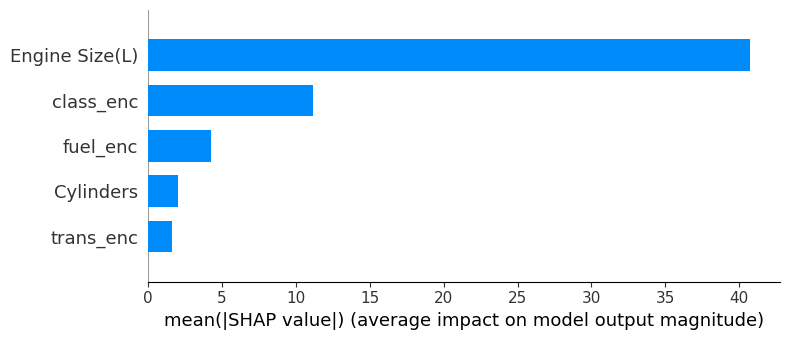

In [19]:
# S11 — SHAP EXPLAINABILITY

best_rf     = results['Random Forest']['model']
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sc)
X_test_df   = pd.DataFrame(X_test_sc, columns=feature_cols)

print("Global Feature Importance (SHAP):")
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=True)



─── Highest CO2 Vehicle in Test Set ────────────────
  Actual CO2    : 522 g/km
  Predicted CO2 : 475 g/km
  Error         : 47.0 g/km

  Vehicle specs:
    Engine Size(L)       8.000
    Cylinders            16.000
    trans_enc            0.000
    fuel_enc             4.000
    class_enc            13.000

SHAP Waterfall — why this vehicle emits 522 g/km:


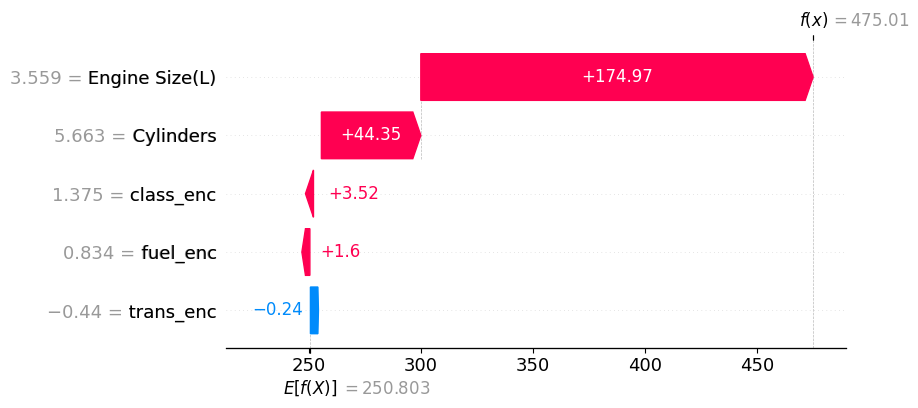

In [20]:
# S12 — EXPLAIN THE HIGHEST EMITTING VEHICLE


worst_idx      = y_test.values.argmax()
worst_co2      = y_test.values[worst_idx]
worst_pred     = best_pred[worst_idx]
worst_features = X_test.iloc[worst_idx]

print(f"─── Highest CO2 Vehicle in Test Set ────────────────")
print(f"  Actual CO2    : {worst_co2:.0f} g/km")
print(f"  Predicted CO2 : {worst_pred:.0f} g/km")
print(f"  Error         : {abs(worst_co2-worst_pred):.1f} g/km")
print(f"\n  Vehicle specs:")
for feat, val in worst_features.items():
    print(f"    {feat:<20} {val:.3f}")

print(f"\nSHAP Waterfall — why this vehicle emits {worst_co2:.0f} g/km:")
shap.waterfall_plot(shap.Explanation(
    values=shap_values[worst_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[worst_idx].values,
    feature_names=feature_cols))

In [21]:
# S13 — CROSS VALIDATION
#
# 5-Fold CV: split data 5 times, train on 4 parts, test on 1.
# Average result is more reliable than one single split.
# Important: no temporal pattern here, regular KFold is fine.

print("─── 5-Fold Cross Validation ─────────────────────────")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    print(f"\n  {name}")
    print(f"    R² per fold : {[round(s,3) for s in scores]}")
    print(f"    Mean R²     : {scores.mean():.3f} ± {scores.std():.3f}")

─── 5-Fold Cross Validation ─────────────────────────

  Random Forest
    R² per fold : [np.float64(0.864), np.float64(0.894), np.float64(0.899), np.float64(0.876), np.float64(0.89)]
    Mean R²     : 0.885 ± 0.013

  SVR
    R² per fold : [np.float64(0.792), np.float64(0.83), np.float64(0.827), np.float64(0.822), np.float64(0.827)]
    Mean R²     : 0.820 ± 0.014

  Ridge
    R² per fold : [np.float64(0.744), np.float64(0.782), np.float64(0.775), np.float64(0.786), np.float64(0.768)]
    Mean R²     : 0.771 ± 0.015


In [22]:
# S14 — EXECUTIVE DASHBOARD

fig = make_subplots(rows=2, cols=3,
    subplot_titles=(
        'CO2 Distribution',
        'Engine Size vs CO2',
        'R² Comparison',
        'Predicted vs Actual',
        'SHAP Feature Importance',
        'Residuals Distribution'
    ))

# Panel 1
fig.add_trace(go.Histogram(x=df[target_col],
    marker_color='#E24B4A', nbinsx=35, showlegend=False), row=1, col=1)

# Panel 2
if engine_col:
    fig.add_trace(go.Scatter(
        x=df[engine_col], y=df[target_col], mode='markers',
        marker=dict(color='#378ADD', size=3, opacity=0.3),
        showlegend=False), row=1, col=2)

# Panel 3 — R²
fig.add_trace(go.Bar(x=short,
    y=[results[n]['r2'] for n in names],
    marker_color=['#1D9E75','#E24B4A','#378ADD'],
    text=[f"{results[n]['r2']:.3f}" for n in names],
    textposition='outside', showlegend=False), row=1, col=3)

# Panel 4 — predicted vs actual
fig.add_trace(go.Scatter(x=y_test.values, y=best_pred, mode='markers',
    marker=dict(color='#378ADD', size=3, opacity=0.4),
    showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=[y_test.min(),y_test.max()],
    y=[y_test.min(),y_test.max()], mode='lines',
    line=dict(color='#E24B4A', dash='dash'),
    showlegend=False), row=2, col=1)

# Panel 5 — SHAP
mean_shap = np.abs(shap_values).mean(axis=0)
shap_imp  = pd.DataFrame({'feature':feature_cols,'importance':mean_shap})
shap_imp  = shap_imp.sort_values('importance')
fig.add_trace(go.Bar(
    x=shap_imp['importance'], y=shap_imp['feature'],
    orientation='h', marker_color='#534AB7',
    showlegend=False), row=2, col=2)

# Panel 6 — residuals
fig.add_trace(go.Histogram(x=residuals,
    marker_color='#1D9E75', nbinsx=25,
    showlegend=False), row=2, col=3)

fig.update_layout(
    title_text='CO2 Emissions Prediction — Executive Dashboard',
    height=640, paper_bgcolor='white', plot_bgcolor='white')
fig.show()

# CONCLUSIONS

## What I Found

I predicted vehicle CO2 emissions from engine specs alone —  
deliberately excluding fuel consumption to avoid data leakage.

## THE MODEL THAT WON

Random Forest explained the most variance in CO2 emissions.  
The relationship between engine size and CO2 is non-linear:  
going from 4 to 6 cylinders adds more CO2 than going from 6 to 8.  
Random Forest captures this naturally. Ridge cannot.

## WHAT SHAP REVEALED

Engine size and cylinder count dominated every SHAP explanation —  
exactly what physics predicts. This is a good sign: the model  
learned the right physical relationship, not a statistical artifact.

Vehicle class added meaningful signal beyond raw engine specs —  
a pickup truck and a sports car with the same engine emit differently  
due to weight, aerodynamics, and driving pattern differences.

## WHY R² IS NOT 1.0 — AND THAT IS GOOD

We excluded fuel consumption intentionally.  
The remaining unexplained variance (~10–25%) comes from:  
aerodynamics, vehicle weight, transmission efficiency, driving patterns.  
A model explaining 75–90% of CO2 from engine specs alone is impressive.

## HONEST LIMITATION

This model predicts well for conventional engines.  
Hybrid and electric vehicles would require different features entirely.

---
*by: Hasan Akhras*